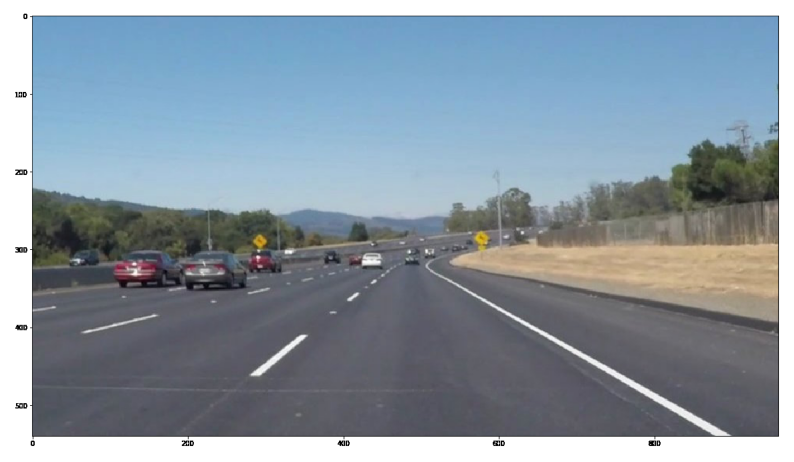

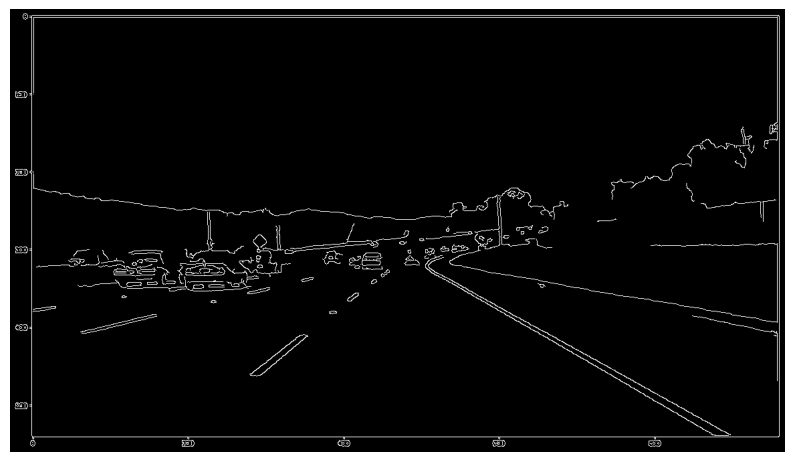

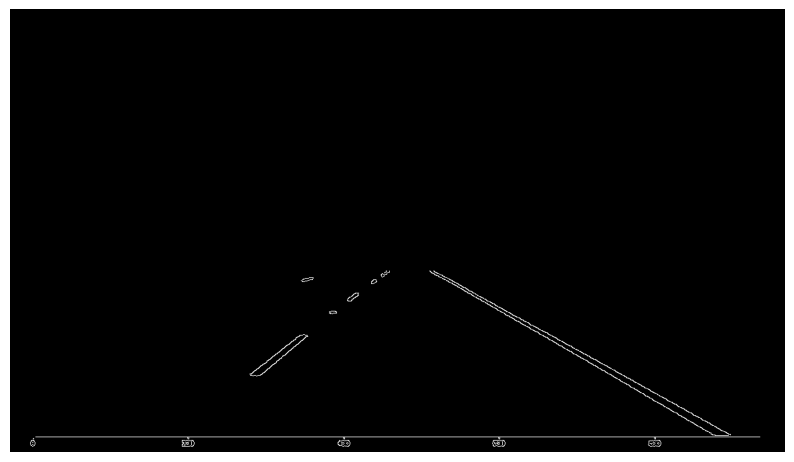

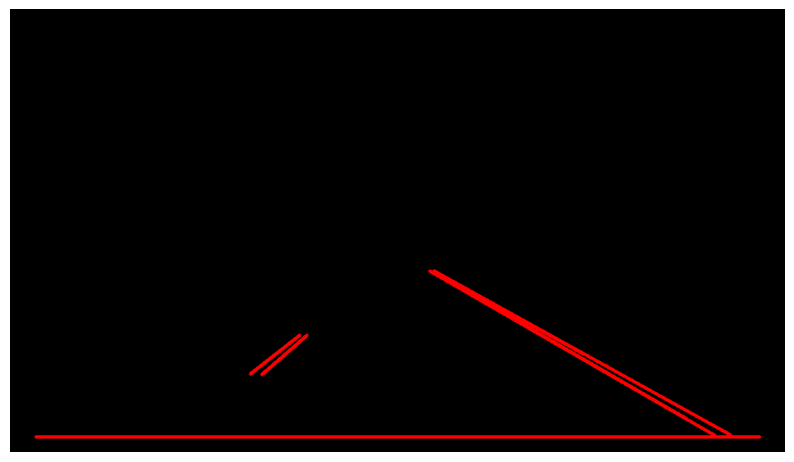

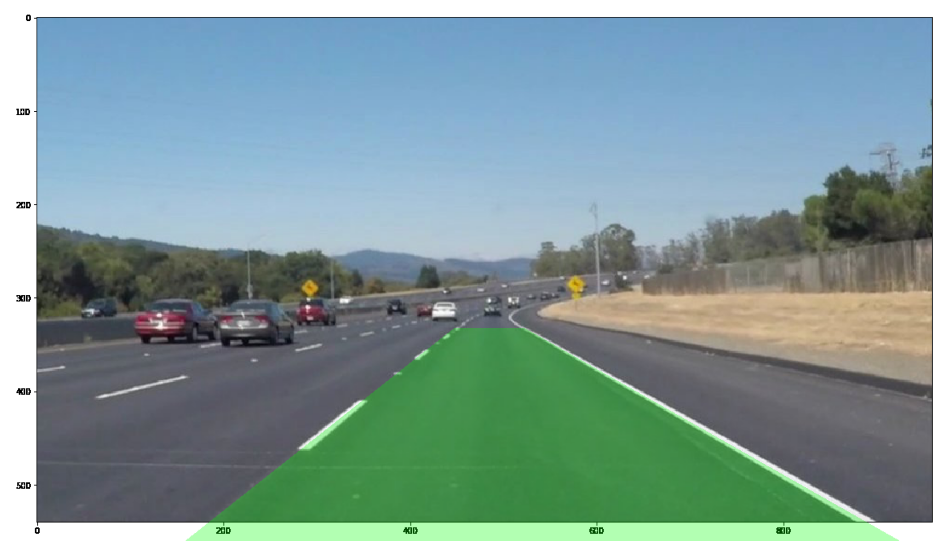

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("lanes.png")

if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)

    plt.figure(figsize=(10,6))
    plt.imshow(edges, cmap="gray")
    plt.axis("off")
    plt.show()

    height, width = edges.shape
    mask = np.zeros_like(edges)

    polygon = np.array([[
        (0, height),
        (width//2 - 120, height//2 + 60),
        (width//2 + 120, height//2 + 60),
        (width, height)
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)
    roi = cv2.bitwise_and(edges, mask)

    plt.figure(figsize=(10,6))
    plt.imshow(roi, cmap="gray")
    plt.axis("off")
    plt.show()

    lines = cv2.HoughLinesP(
        roi,
        1,
        np.pi/180,
        threshold=50,
        minLineLength=50,
        maxLineGap=30
    )

    line_img = np.zeros_like(img)

    left_lines = []
    right_lines = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_img, (x1,y1), (x2,y2), (255,0,0), 3)

            if x2 == x1:
                continue

            slope = (y2-y1)/(x2-x1)
            
            if slope < -0.5:
                left_lines.append(line[0])
            elif slope > 0.5:
                right_lines.append(line[0])

    plt.figure(figsize=(10,6))
    plt.imshow(line_img)
    plt.axis("off")
    plt.show()

    def average_line(lines):
        if len(lines) == 0:
            return None
        x_coords = []
        y_coords = []
        for x1, y1, x2, y2 in lines:
            x_coords.extend([x1, x2])
            y_coords.extend([y1, y2])
        return np.polyfit(x_coords, y_coords, 1)

    left_fit = average_line(left_lines)
    right_fit = average_line(right_lines)

    if left_fit is not None and right_fit is not None:
        y1 = height
        y2 = int(height * 0.6)

        left_x1 = int((y1 - left_fit[1]) / left_fit[0])`
        left_x2 = int((y2 - left_fit[1]) / left_fit[0])

        right_x1 = int((y1 - right_fit[1]) / right_fit[0])
        right_x2 = int((y2 - right_fit[1]) / right_fit[0])

        overlay = img.copy()
        pts = np.array([[
            (left_x1, y1),
            (left_x2, y2),
            (right_x2, y2),
            (right_x1, y1)
        ]], dtype=np.int32)

        cv2.fillPoly(overlay, pts, (0, 255, 0))
        result = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

        plt.figure(figsize=(12,8))
        plt.imshow(result)
        plt.axis("off")
        plt.show()
    else:
        print("Could not reliably detect both left and right lane markers to create the overlay.")
else:
    print("Error: Image could not be loaded. Check the file path.")